# Flight Delay Prediction — Heathrow (EGLL)
## Exploratory Notebook Sandbox

This notebook is an exploratory sandbox for Machine Learning Operations (MLOps) development.

**Use it to**
- Inspect raw and cleaned flight/weather data
- Perform focused Exploratory Data Analysis (EDA) checks to validate assumptions
- Run quick training and inference checks while iterating on features
- Experiment with new features and models to improve delay prediction metrics

**Do not use it to**
- Replace the reproducible pipeline in `src/main.py`
- Store production logic in notebook cells
- Write production artifacts (CSVs, models, predictions) to disk from the notebook

**Canonical production entry point**
- Run from terminal: `python -m src.main`

**Why this separation matters**
- The orchestrator (`src/main.py`) is the factory: deterministic inputs, deterministic outputs, clear provenance
- The notebook is the lab bench: interactive inspection, rapid iteration, visible intermediate states and exploration
- Writing artifacts from both places creates conflicting versions and breaks the audit trail

### A) Environment Setup and Imports

**Learning intent**
- Make imports reliable regardless of how you opened Jupyter
- Ensure relative paths behave the same way for everyone on the team
- Keep notebook code thin by calling functions from `src/` modules
- `%autoreload 2` means any edits you make to `src/` files are picked up without restarting the kernel

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from __future__ import annotations

import os       # For changing the working directory to the repo root
import sys      # For manipulating sys.path so imports work regardless of where Jupyter was launched
from pathlib import Path  # Platform-independent path handling

import pandas as pd
import numpy as np
from IPython.display import display  # For rendering DataFrames nicely in Jupyter

# ── Repo root alignment ───────────────────────────────────────────────────────
# Problem this solves:
#   Notebooks can start with different working directories depending on how
#   Jupyter was launched (from repo root vs. from notebooks/ folder vs. VS Code).
#   Relative paths then break unpredictably across teammates' machines.
#
# Approach:
#   Walk upward from the current folder until we find one containing `src/`.
#   Set that as the working directory so relative paths match the orchestrator.
def find_repo_root(start: Path, marker_dir: str = "src", max_hops: int = 12) -> Path:
    current = start.resolve()
    for _ in range(max_hops):
        if (current / marker_dir).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError(
        f"Could not find repo root containing '{marker_dir}/' starting from: {start}\n"
        "Make sure you opened the correct repository folder."
    )

PROJECT_ROOT = find_repo_root(Path.cwd())
os.chdir(PROJECT_ROOT)

# Ensure `import src...` works even if Jupyter started elsewhere
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())

# ── Imports from production modules ──────────────────────────────────────────
# Note: we intentionally do NOT import from src/main.py to avoid side effects
# (main.py writes files to disk; we want sandbox execution only)
from src.load_data import load_raw_data
from src.clean_data import clean_dataframe
from src.validate import validate_dataframe
from src.features import get_feature_preprocessor
from src.train import train_model
from src.evaluate import evaluate_model
from src.infer import run_inference

PROJECT_ROOT: /Users/Caspar/Documents/IE/MLOPS/fork/final testing
cwd: /Users/Caspar/Documents/IE/MLOPS/fork/final testing


### B) Sandbox Configuration

**Guideline**
- Keep configuration in one place so changes propagate everywhere in the notebook
- Mirror the same structure as `config.yaml` / `SETTINGS` in the orchestrator
- Prefer explicit column lists over clever inference — errors are easier to debug

**Teaching point: `config.yaml` vs. hardcoded SETTINGS**
- The orchestrator reads from `config.yaml` for reproducibility across environments
- In the sandbox we define SETTINGS inline so you can tweak and experiment freely
- When your experiment works, promote the change to `config.yaml`, not the other way around

In [22]:
import yaml

CONFIG_PATH = PROJECT_ROOT / "config.yaml"

# Load the canonical config so the sandbox stays aligned with the orchestrator
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print("Loaded config from:", CONFIG_PATH)
print()
for k, v in config.items():
    print(f"  {k}: {v}")

Loaded config from: /Users/Caspar/Documents/IE/MLOPS/fork/final testing/config.yaml

  airport: {'icao': 'EGLL', 'name': 'London Heathrow', 'latitude': 51.4775, 'longitude': -0.4614}
  data: {'start_date': '2023-06-01', 'end_date': '2023-08-31', 'delay_threshold_minutes': 15, 'weather_variables': ['temperature_2m', 'precipitation', 'windspeed_10m', 'winddirection_10m', 'weathercode', 'cloudcover'], 'raw_path': 'data/raw/flights_raw.csv', 'processed_path': 'data/processed/flights_clean.csv'}
  target_column: delayed
  problem_type: classification
  features: {'quantile_bin': ['windspeed_10m'], 'numeric_passthrough': ['temperature_2m', 'precipitation', 'cloudcover', 'flight_duration_s'], 'binary_sum_cols': ['is_foggy', 'is_stormy', 'is_night_departure', 'is_weekend'], 'categorical_onehot': [], 'n_bins': 4}
  split: {'test_size': 0.05, 'val_size': 0.15, 'random_state': 42}
  validation: {'check_missing_values': True, 'numeric_non_negative_cols': ['windspeed_10m', 'precipitation', 'cloudco

In [23]:
# ── Derive commonly used paths from config ────────────────────────────────────
AIRPORT_ICAO = config.get("airport_icao", "EGLL")
TARGET_COL   = config.get("target_column", "is_delayed")
PROBLEM_TYPE = config.get("problem_type", "classification")

# Sandbox helper: three-way train/val/test split
# We define this here rather than importing from src/main.py to avoid disk writes.
def three_way_split(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    test_size: float,
    val_size: float,
    random_state: int,
    stratify: bool,
):
    """
    Sandbox copy aligned with the orchestrator intent.

    Why we define it here and not import it:
    - src/main.py is the factory; calling it triggers artifact writes
    - Students benefit from seeing the leakage gate explicitly

    Behaviour:
    - Try stratified splits for classification (preserves class balance)
    - If stratification fails, fall back to random splits with a clear message
    """
    from sklearn.model_selection import train_test_split

    if test_size <= 0 or val_size <= 0 or (test_size + val_size) >= 1.0:
        raise ValueError(
            "Split sizes must satisfy: 0 < test_size, 0 < val_size, test_size + val_size < 1"
        )

    stratify_y = y if stratify else None

    try:
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_state,
            stratify=stratify_y,
        )
        relative_val_size = val_size / (1.0 - test_size)
        stratify_temp = y_temp if stratify else None
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp,
            test_size=relative_val_size,
            random_state=random_state,
            stratify=stratify_temp,
        )
        return X_train, X_val, X_test, y_train, y_val, y_test

    except ValueError as e:
        print(f"[notebook] Stratified split failed: {e}")
        print("[notebook] Falling back to random split")
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        relative_val_size = val_size / (1.0 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=relative_val_size, random_state=random_state
        )
        return X_train, X_val, X_test, y_train, y_val, y_test


print("AIRPORT_ICAO :", AIRPORT_ICAO)
print("TARGET_COL   :", TARGET_COL)
print("PROBLEM_TYPE :", PROBLEM_TYPE)

AIRPORT_ICAO : EGLL
TARGET_COL   : delayed
PROBLEM_TYPE : classification


### 1) Load Raw Data (`src.load_data`)

**Educational note**
- Raw data is loaded exactly once and treated as immutable input
- We call `load_raw_data()` from the production module — no custom loading logic here
- If the raw data shape changes, investigate the source, do not patch the notebook

**Flight delay context**
- Raw data contains synthetic Heathrow (EGLL) flight records with weather attributes
- Each row represents one flight departure with associated weather and schedule information
- The `generate_sample()` function in `load_data.py` produces reproducible synthetic data

In [24]:
df_raw = load_raw_data(CONFIG_PATH)

print("df_raw.shape:", df_raw.shape)
print("Columns     :", df_raw.columns.tolist())
df_raw.head()

df_raw.shape: (55973, 23)
Columns     : ['icao24', 'firstSeen', 'estDepartureAirport', 'lastSeen', 'estArrivalAirport', 'callsign', 'estDepartureAirportHorizDistance', 'estDepartureAirportVertDistance', 'estArrivalAirportHorizDistance', 'estArrivalAirportVertDistance', 'departureAirportCandidatesCount', 'arrivalAirportCandidatesCount', 'departure_dt', 'datetime', 'temperature_2m', 'precipitation', 'windspeed_10m', 'winddirection_10m', 'weathercode', 'visibility', 'cloudcover', 'flight_duration_s', 'delayed']


,icao24,firstSeen,estDepartureAirport,lastSeen,estArrivalAirport,callsign,estDepartureAirportHorizDistance,estDepartureAirportVertDistance,estArrivalAirportHorizDistance,estArrivalAirportVertDistance,...,datetime,temperature_2m,precipitation,windspeed_10m,winddirection_10m,weathercode,visibility,cloudcover,flight_duration_s,delayed
0,4078b8,1685656700,EGLL,1685697167,SBMT,BAW247,1531,20,4285.0,665.0,...,2023-06-01 21:00:00,12.2,0.0,19.7,38.0,3.0,NaN,100.0,40467,1
1,a14bdd,1685656573,EGLL,1685693666,MMMX,AMX008,1339,17,6996.0,223.0,...,2023-06-01 21:00:00,12.2,0.0,19.7,38.0,3.0,NaN,100.0,37093,0
2,4bb26a,1685656448,EGLL,1685668257,LTFM,THY4NY,1405,50,4872.0,259.0,...,2023-06-01 21:00:00,12.2,0.0,19.7,38.0,3.0,NaN,100.0,11809,0
3,010206,1685656294,EGLL,1685669967,NaN,MSR780,1457,50,NaN,NaN,...,2023-06-01 21:00:00,12.2,0.0,19.7,38.0,3.0,NaN,100.0,13673,0
4,89408b,1685656101,EGLL,1685677418,OBBI,GFA006,1764,2,20287.0,859.0,...,2023-06-01 21:00:00,12.2,0.0,19.7,38.0,3.0,NaN,100.0,21317,0


### 2) Focused EDA Checks

**Goal**
- Validate assumptions before investing in feature engineering and training

**Guideline**
- Prefer small, targeted checks over sprawling EDA cells
- If an assumption is wrong, fix the pipeline module — not the notebook
- These checks mirror what `validate.py` enforces programmatically

In [25]:
# ── 2a) Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
missing = df_raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0] if missing.any() else missing.head(10))

# ── 2b) Target distribution ───────────────────────────────────────────────────
if TARGET_COL in df_raw.columns:
    vc = df_raw[TARGET_COL].value_counts(dropna=False)
    print(f"\nTarget distribution ('{TARGET_COL}'):")
    display(vc)
    prevalence = float(vc.get(1, 0) / vc.sum())
    print(f"Positive class prevalence (delayed >15 min): {prevalence:.1%}")
else:
    print(f"\nTarget column '{TARGET_COL}' not found — check load_data.py")

# ── 2c) Delay minutes distribution ───────────────────────────────────────────
delay_col = "dep_delay_min"
if delay_col in df_raw.columns:
    print(f"\nDeparture delay summary ('{delay_col}'):")
    display(df_raw[delay_col].describe())

# ── 2d) Dtypes snapshot ───────────────────────────────────────────────────────
print("\nColumn dtypes:")
display(df_raw.dtypes.to_frame(name="dtype"))

Missing values per column:


visibility                        55973
estArrivalAirport                  5400
estArrivalAirportHorizDistance     5400
estArrivalAirportVertDistance      5400
datetime                              7
cloudcover                            7
weathercode                           7
winddirection_10m                     7
windspeed_10m                         7
precipitation                         7
temperature_2m                        7
dtype: int64


Target distribution ('delayed'):


delayed
0    52046
1     3927
Name: count, dtype: int64

Positive class prevalence (delayed >15 min): 7.0%

Column dtypes:


,dtype
icao24,object
firstSeen,int64
estDepartureAirport,object
lastSeen,int64
estArrivalAirport,object
callsign,object
estDepartureAirportHorizDistance,int64
estDepartureAirportVertDistance,int64
estArrivalAirportHorizDistance,float64
estArrivalAirportVertDistance,float64


In [26]:
# ── 2e) Weather feature distributions ────────────────────────────────────────
weather_cols = [c for c in df_raw.columns if c in [
    "temperature_2m", "precipitation", "windspeed_10m",
    "winddirection_10m", "weathercode", "visibility", "cloudcover"
]]

if weather_cols:
    print("Weather feature summary:")
    display(df_raw[weather_cols].describe().round(2))
else:
    print("No weather columns detected — check load_data.py column definitions")

# ── 2f) Airline / route distribution ─────────────────────────────────────────
for cat_col in ["airline", "aircraft_type", "destination"]:
    if cat_col in df_raw.columns:
        print(f"\nTop 10 '{cat_col}' values:")
        display(df_raw[cat_col].value_counts().head(10))

Weather feature summary:


,temperature_2m,precipitation,windspeed_10m,winddirection_10m,weathercode,visibility,cloudcover
count,55966.00,55966.00,55966.00,55966.00,55966.00,0.0,55966.00
mean,19.05,0.11,14.78,201.89,12.87,NaN,61.69
std,3.34,0.46,6.08,86.57,21.14,NaN,38.40
min,9.10,0.00,0.80,5.00,0.00,NaN,0.00
25%,16.90,0.00,10.30,148.00,1.00,NaN,24.00
50%,18.90,0.00,14.80,228.00,3.00,NaN,71.00
75%,21.20,0.00,18.70,259.00,3.00,NaN,100.00
max,29.00,7.80,41.30,360.00,65.00,NaN,100.00


### 3) Clean Data (`src.clean_data`)

**Educational note**
- Cleaning must be deterministic: same input → same output every run
- Cleaning must not learn from the data in a way that leaks information across splits
  - ✅ OK: dropping duplicate rows, renaming columns, casting types
  - ❌ Not OK: imputing with the dataset mean (fit on full data before splitting)

**Sandbox constraint**
- `clean_dataframe()` returns a cleaned DataFrame in memory
- The notebook does **not** save this to `data/processed/clean.csv`
- Only `src/main.py` writes canonical artifacts to disk

In [27]:
df_clean = clean_dataframe(df_raw, target_column=config["target_column"])

print("df_raw.shape  :", df_raw.shape)
print("df_clean.shape:", df_clean.shape)
print(f"Rows removed  : {df_raw.shape[0] - df_clean.shape[0]}")
df_clean.head()

[DEBUG] cols after rename: ['weathercode']
[DEBUG] cols after flags: ['is_foggy', 'is_stormy', 'is_night_departure', 'is_weekend']
[DEBUG] final cols: ['delayed', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloudcover', 'flight_duration_s', 'is_foggy', 'is_stormy', 'is_night_departure', 'is_weekend']
df_raw.shape  : (55973, 23)
df_clean.shape: (55973, 10)
Rows removed  : 0


,delayed,temperature_2m,precipitation,windspeed_10m,cloudcover,flight_duration_s,is_foggy,is_stormy,is_night_departure,is_weekend
0,1,12.2,0.0,19.7,100.0,40467,0,0,0,0
1,0,12.2,0.0,19.7,100.0,37093,0,0,0,0
2,0,12.2,0.0,19.7,100.0,11809,0,0,0,0
3,0,12.2,0.0,19.7,100.0,13673,0,0,0,0
4,0,12.2,0.0,19.7,100.0,21317,0,0,0,0


In [28]:
# ── Cleaning audit: compare before vs. after ──────────────────────────────────
print("Missing values after cleaning:")
post_missing = df_clean.isna().sum().sort_values(ascending=False)
display(post_missing[post_missing > 0] if post_missing.any() else pd.Series({"(none)": 0}))

print("\nDuplicate rows after cleaning:", df_clean.duplicated().sum())

if TARGET_COL in df_clean.columns:
    print(f"\nTarget distribution after cleaning ('{TARGET_COL}'):")
    display(df_clean[TARGET_COL].value_counts(dropna=False))

Missing values after cleaning:


(none)    0
dtype: int64


Duplicate rows after cleaning: 200

Target distribution after cleaning ('delayed'):


delayed
0    52046
1     3927
Name: count, dtype: int64

### 4) Validate Data (`src.validate`)

**Purpose**
- Validation is the quality gate that prevents silent failures downstream
- It runs after cleaning and before any feature engineering or training

**Teaching point: Fail-Fast Security Gates**
- Better to crash here with a clear message than to silently train on bad data
- `validate_dataframe()` checks schema, types, value ranges, and required columns
- If validation raises an exception, the root cause is in the data or cleaning step

**Sandbox behaviour**
- We call the same `validate_dataframe()` used by the orchestrator
- In the sandbox, a validation failure is informative — inspect and iterate
- In production (via `main.py`), a validation failure halts the entire pipeline

In [29]:
try:
    val_cfg = config.get("validation", {})
    validate_dataframe(
        df_clean,
        required_columns=list(df_clean.columns),
        check_missing_values=val_cfg.get("check_missing_values", True),
        target_column=config.get("target_column"),
        target_allowed_values=[0, 1],
        numeric_non_negative_cols=val_cfg.get("numeric_non_negative_cols", []),
    )
    print("[notebook] Validation passed ✅")
except Exception as e:
    print(f"[notebook] Validation failed ❌\n  {type(e).__name__}: {e}")
    print("\n  → Fix the issue in clean_data.py or load_data.py, then re-run from cell 1.")

[notebook] Validation passed ✅


### 5) Split Data (Leakage Prevention Gate)

**Teaching point: The Leakage Gate**
- We split the data **before** fitting any feature recipe (scaler, encoder, etc.)
- If we fit a scaler on the full dataset and then split, the test set has "seen" the training data
  — this is data leakage and produces optimistically biased evaluation metrics
- The correct order is always: **Split → Fit preprocessor on train → Transform all splits**

**Split strategy**
- `train`: model learning
- `val`: hyperparameter tuning, early stopping decisions
- `test`: final, held-back evaluation (touch only once at the very end)

In [30]:
# Separate features from target
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

split_cfg = config.get("split", {"test_size": 0.05, "val_size": 0.15, "random_state": 42})

X_train, X_val, X_test, y_train, y_val, y_test = three_way_split(
    X, y,
    test_size=split_cfg["test_size"],
    val_size=split_cfg["val_size"],
    random_state=split_cfg["random_state"],
    stratify=(PROBLEM_TYPE == "classification"),
)

print(f"Total rows   : {len(df_clean)}")
print(f"X_train shape: {X_train.shape}  |  y_train positive rate: {y_train.mean():.3f}")
print(f"X_val shape  : {X_val.shape}   |  y_val positive rate:   {y_val.mean():.3f}")
print(f"X_test shape : {X_test.shape}  |  y_test positive rate:  {y_test.mean():.3f}")
print("\nClass balance is preserved across splits ✅" if abs(y_train.mean() - y_test.mean()) < 0.05
      else "\n⚠️  Class balance differs between splits — check stratification")

Total rows   : 55973
X_train shape: (44778, 9)  |  y_train positive rate: 0.070
X_val shape  : (8396, 9)   |  y_val positive rate:   0.070
X_test shape : (2799, 9)  |  y_test positive rate:  0.070

Class balance is preserved across splits ✅


### 6) Build Feature Preprocessor (`src.features`)

**Teaching point: Fit on train, transform all**
- The preprocessor is a `sklearn.Pipeline` object — it encapsulates all transformations
- We call `.fit()` **only on `X_train`**
- We then call `.transform()` on train, val, and test independently
- This guarantees that statistics (bin edges, one-hot categories) are derived only from training data

**Features for flight delay prediction**
- Quantile-binned continuous features: `wind_speed_kt`, `dep_delay_min`, etc.
- One-hot encoded categoricals: `airline`, `aircraft_type`
- Binary passthrough: `is_weekend`, `is_peak_hour`
- Numeric passthrough: `visibility_m`, `temp_c`, `precip_mm`

In [31]:
feat_cfg = config.get("features", {})

preprocessor = get_feature_preprocessor(
    quantile_bin_cols=feat_cfg.get("quantile_bin", []),
    categorical_onehot_cols=feat_cfg.get("categorical_onehot", []),
    numeric_passthrough_cols=feat_cfg.get("numeric_passthrough", []),
    binary_sum_cols=feat_cfg.get("binary_sum_cols", []),
    n_bins=feat_cfg.get("n_bins", 4),
)

# Fit on training data ONLY (leakage prevention)
preprocessor.fit(X_train)

# Transform all three splits
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

print("Preprocessor fitted on X_train ✅")
print(f"Transformed shapes — train: {X_train_t.shape}, val: {X_val_t.shape}, test: {X_test_t.shape}")

# Inspect the feature names produced by the preprocessor
try:
    feature_names = preprocessor.get_feature_names_out()
    print(f"\nFeatures produced ({len(feature_names)}):")
    for name in feature_names:
        print("  ", name)
except AttributeError:
    print("\n(Preprocessor does not expose get_feature_names_out — inspect steps manually)")

Preprocessor fitted on X_train ✅
Transformed shapes — train: (44778, 6), val: (8396, 6), test: (2799, 6)

(Preprocessor does not expose get_feature_names_out — inspect steps manually)


### 7) Train Model (`src.train`)

**Educational note**
- We call `train_model()` from the production module — training logic stays in `src/train.py`
- The returned `model_pipeline` bundles the preprocessor + classifier into a single sklearn Pipeline
- Bundling prevents training-serving skew: the exact same transformations are applied at inference time

**Teaching point: Why bundle preprocessor + model?**
- If you save only the classifier weights, you must manually reconstruct preprocessing at inference
- Any mismatch between training and serving transformations silently degrades predictions
- A bundled `Pipeline` object is the single deployable artifact — one file, zero ambiguity

In [32]:
model_pipeline = train_model(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    problem_type=config.get("problem_type", "classification"),
)

print("[notebook] Model trained in memory ✅")
print("Pipeline steps:")
for name, step in model_pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

# Sandbox note: we do NOT save the model here.
# Only `python -m src.main` writes models/model.joblib
print("\n⚠️  Model lives in memory only — run `python -m src.main` to persist to disk.")

[notebook] Model trained in memory ✅
Pipeline steps:
  preprocessor: ColumnTransformer
  model: RandomForestClassifier

⚠️  Model lives in memory only — run `python -m src.main` to persist to disk.


### 8) Evaluate Model (`src.evaluate`)

**Evaluation strategy**
- Primary metric: **F1-Score** (balances precision and recall for imbalanced delay labels)
- We evaluate on `val` during iteration — `test` is held back until the final model

**Teaching point: Why not just use accuracy?**
- Flight delays are relatively rare (~20–30% of flights) — accuracy is misleadingly high
- A model that always predicts "on time" achieves ~75% accuracy but catches zero delays
- F1-Score penalises both missed delays (low Recall) and false alarms (low Precision)

**Sandbox vs. orchestrator**
- The sandbox lets you evaluate on `val` and experiment with thresholds safely
- `evaluate_on_test: False` in the orchestrator config preserves the test set as a final holdout

In [ ]:
# ── Evaluate on validation set ────────────────────────────────────────────────
print("=" * 50)
print("VALIDATION SET METRICS")
print("=" * 50)
val_metrics = evaluate_model(
    model=model_pipeline,
    X_eval=X_val,
    y_eval=y_val,
    problem_type=config.get("problem_type", "classification"),
)
display(pd.DataFrame([val_metrics]))

VALIDATION SET METRICS


,precision_0,recall_0,precision_1,recall_1,accuracy,f1,roc_auc,pr_auc,brier,fnr
0,0.948357,0.976175,0.483333,0.295416,0.928418,0.366702,0.837358,0.385337,0.055676,0.704584


In [ ]:
# ── Optional: evaluate on test set ───────────────────────────────────────────
EVALUATE_ON_TEST = False  # ← flip to True only for your final evaluation

if EVALUATE_ON_TEST:
    print("=" * 50)
    print("TEST SET METRICS (FINAL EVALUATION)")
    print("=" * 50)
    test_metrics = evaluate_model(
        model=model_pipeline,
        X_eval=X_test,
        y_eval=y_test,
        problem_type=config.get("problem_type", "classification"),
    )
    display(pd.DataFrame([test_metrics]))
else:
    print("[notebook] Test set evaluation skipped — set EVALUATE_ON_TEST = True for final run.")

[notebook] Test set evaluation skipped — set EVALUATE_ON_TEST = True for final run.


### 9) Run Inference (`src.infer`)

**What inference means here**
- We feed new (unseen) flight records into the trained model and get predicted delay flags + probabilities
- In production, the input would come from a live feed of scheduled departures
- In the sandbox, we use a sample from `X_test` as a stand-in for new data

**Teaching point: Probability scores vs. binary labels**
- The model outputs a probability score (0–1) for each flight
- The binary label (`1 = delayed`) is derived by applying a decision threshold (default: 0.5)
- In practice, care managers / operations teams might prefer a lower threshold to catch more delays
  at the cost of more false alarms — this is a business decision, not a model decision

**Sandbox constraint**
- We display predictions in memory only
- The notebook does **not** write `reports/predictions.csv`

In [ ]:
sample_n = min(10, len(X_test))
X_infer_sample = X_test.sample(n=sample_n, random_state=config.get("split", {}).get("random_state", 42))

df_predictions = run_inference(
    model=model_pipeline,
    X_infer=X_infer_sample,
    include_proba=(PROBLEM_TYPE == "classification"),
)

print("[notebook] Inference results (in-memory only, not saved to disk)")
display(df_predictions.head(10))

[notebook] Inference results (in-memory only, not saved to disk)


,prediction,probability
53254,0,0.00
37900,0,0.00
20464,0,0.00
33323,0,0.00
34272,0,0.00
38857,0,0.06
39444,1,0.51
47308,0,0.02
53149,0,0.30
28755,0,0.00


### 10) Sandbox Experiment Area — Free Exploration

Use the cells below to experiment freely:

- Try different feature sets or feature engineering ideas
- Adjust model hyperparameters in the config dict and re-train
- Visualise decision boundaries or feature importances
- Test edge cases: very low visibility, strong crosswinds, night flights

**Promotion rule**: when something works here, promote it to the appropriate `src/` module — not the other way around.

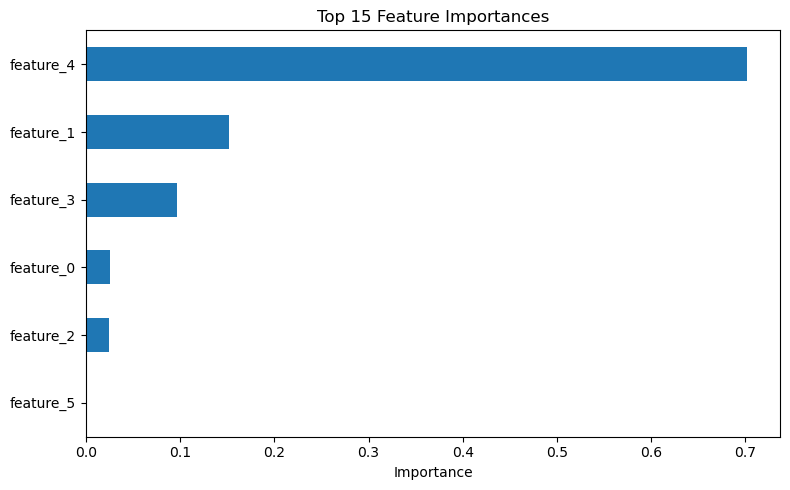

In [ ]:
# ── Feature importance (if model exposes it) ──────────────────────────────────
import matplotlib.pyplot as plt

classifier_step = model_pipeline.steps[-1][1]  # Last step is the estimator

if hasattr(classifier_step, "feature_importances_"):
    try:
        feature_names = model_pipeline.steps[-2][1].get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(len(classifier_step.feature_importances_))]

    importances = pd.Series(classifier_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax)
    ax.set_title("Top 15 Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Classifier does not expose feature_importances_ — try a tree-based model.")

In [ ]:
# ── Threshold sensitivity analysis ───────────────────────────────────────────
# Teaching point: moving the decision threshold shifts the precision/recall trade-off
from sklearn.metrics import precision_score, recall_score, f1_score

if PROBLEM_TYPE == "classification" and hasattr(model_pipeline, "predict_proba"):
    y_proba_val = model_pipeline.predict_proba(X_val)[:, 1]
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    rows = []
    for t in thresholds:
        y_pred_t = (y_proba_val >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_val, y_pred_t, zero_division=0),
            "recall":    recall_score(y_val, y_pred_t, zero_division=0),
            "f1":        f1_score(y_val, y_pred_t, zero_division=0),
            "n_flagged": y_pred_t.sum(),
        })
    df_thresh = pd.DataFrame(rows).set_index("threshold")
    print("Threshold sensitivity on validation set:")
    display(df_thresh.round(3))
else:
    print("Threshold analysis requires a classification model with predict_proba.")

Threshold sensitivity on validation set:


,precision,recall,f1,n_flagged
threshold,,,,
0.3,0.374,0.428,0.399,673
0.4,0.425,0.357,0.388,494
0.5,0.478,0.301,0.369,370
0.6,0.558,0.229,0.325,242
0.7,0.632,0.154,0.248,144


### 11) Inspect Production Artifacts (post-orchestrator run)

This notebook does **not** write artifacts to disk.

Use this cell only **after** running the orchestrator from the terminal:
```bash
python -m src.main
```

**Goal**
- Prove that the factory output exists on disk
- Inspect outputs without modifying them
- Cross-check that the orchestrator and sandbox produce consistent results

In [ ]:
import joblib

CLEAN_DATA_PATH  = PROJECT_ROOT / "data" / "processed" / "flights_clean.csv"
MODEL_PATH       = PROJECT_ROOT / "models" / "model.joblib"
PREDICTIONS_PATH = PROJECT_ROOT / "reports" / "predictions.csv"

try:
    clean_from_disk = pd.read_csv(CLEAN_DATA_PATH)
    preds_from_disk = pd.read_csv(PREDICTIONS_PATH)
    model_from_disk = joblib.load(MODEL_PATH)

    print("clean.csv shape    :", clean_from_disk.shape)
    print("predictions shape  :", preds_from_disk.shape)
    print("loaded model type  :", type(model_from_disk))

    display(preds_from_disk.head(10))

except FileNotFoundError as e:
    print("Artifacts not found yet — run the orchestrator first:")
    print("  python -m src.main")
    print(f"  Missing: {e.filename}")
except Exception as e:
    print(f"Could not load artifacts: {type(e).__name__}: {e}")

clean.csv shape    : (55973, 10)
predictions shape  : (2799, 3)
loaded model type  : <class 'sklearn.pipeline.Pipeline'>


,Unnamed: 0,prediction,probability
0,23291,0,0.00
1,48647,0,0.00
2,45200,0,0.32
3,39872,0,0.01
4,39206,0,0.37
5,49169,0,0.00
6,15214,0,0.00
7,19957,0,0.00
8,49498,0,0.00
9,30117,0,0.02
